# Motivation Figure: Relational Gap in Half-Truth Performance

A grouped bar chart showing that while baselines fix Entity errors, they fail to fix Relational errors.

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import tueplots
from tueplots import figsizes, fontsizes
from tueplots.constants.color import palettes

# ICML 2024 configuration
plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())

# Use a clean style with black text
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Use tueplots built-in colorblind-friendly palette (Paul Tol's bright)
# Add '#' prefix if needed
COLORBLIND_PALETTE = [f"#{c}" if not c.startswith("#") else c for c in palettes.paultol_bright]

# =============================================================================
# CONFIGURATION
# =============================================================================

RESULTS_BASE_DIR = "../../results_new"

# Models for motivation figure (subset)
MOTIVATION_MODELS = {
    "CLIP": "half_truth_coco_00_baseline_openai_vitb32",
    "NegCLIP": "half_truth_coco_negclip_coco_vitb32",
    "SigLIP": "half_truth_coco_siglip_vitb16",
    "SigLIP2": "half_truth_coco_siglip2_vitb16"
}

# Exclude negation samples
EXCLUDED_CONDITIONS = ['relation_negation']

# =============================================================================
# LOADING FUNCTIONS
# =============================================================================

def load_model_results(base_dir, model_folder):
    """Load results for a single model."""
    model_path = Path(base_dir) / model_folder
    results_file = model_path / 'results.json'
    
    if results_file.exists():
        with open(results_file, 'r') as f:
            data = json.load(f)
            if 'results' in data:
                return pd.DataFrame(data['results'])
            else:
                return pd.DataFrame(data)
    return None


def load_all_models(base_dir, models):
    """Load results for all models."""
    all_results = {}
    
    for display_name, folder_name in models.items():
        print(f"Loading {display_name}...")
        try:
            df = load_model_results(base_dir, folder_name)
            if df is not None:
                df['model'] = display_name
                # Filter out excluded conditions
                df = df[~df['condition'].isin(EXCLUDED_CONDITIONS)]
                all_results[display_name] = df
                print(f"  ✓ Loaded {len(df)} results (excluded: {EXCLUDED_CONDITIONS})")
            else:
                print(f"  ⚠ No results found")
        except Exception as e:
            print(f"  ✗ Error: {e}")
    
    return all_results


# Load data
print("="*60)
print("LOADING HALF-TRUTH RESULTS FOR MOTIVATION FIGURE")
print(f"Excluding conditions: {EXCLUDED_CONDITIONS}")
print("="*60)

all_model_results = load_all_models(RESULTS_BASE_DIR, MOTIVATION_MODELS)
print(f"\n✓ Loaded {len(all_model_results)} models: {list(all_model_results.keys())}")

LOADING HALF-TRUTH RESULTS FOR MOTIVATION FIGURE
Excluding conditions: ['relation_negation']
Loading CLIP...
  ✓ Loaded 29849 results (excluded: ['relation_negation'])
Loading NegCLIP...
  ✓ Loaded 29849 results (excluded: ['relation_negation'])
Loading SigLIP...
  ✓ Loaded 29849 results (excluded: ['relation_negation'])
Loading SigLIP...
  ✓ Loaded 29849 results (excluded: ['relation_negation'])
Loading SigLIP2...
  ✓ Loaded 29849 results (excluded: ['relation_negation'])

✓ Loaded 4 models: ['CLIP', 'NegCLIP', 'SigLIP', 'SigLIP2']
  ✓ Loaded 29849 results (excluded: ['relation_negation'])
Loading SigLIP2...
  ✓ Loaded 29849 results (excluded: ['relation_negation'])

✓ Loaded 4 models: ['CLIP', 'NegCLIP', 'SigLIP', 'SigLIP2']


In [2]:
# =============================================================================
# COMPUTE ENTITY VS RELATION AVERAGES
# =============================================================================

# Match condition definitions from ht_latex_table.ipynb for consistency
ENTITY_CONDITIONS = ['component_easy', 'component_hard', 'component_random']
RELATION_CONDITIONS = ['attribute_wrong', 'object_wrong', 'relation_antonym', 
                       'relation_swap', 'subject_wrong']

def get_category(condition):
    """Categorize condition as Entity or Relation."""
    if condition in ENTITY_CONDITIONS:
        return 'Entity'
    elif condition in RELATION_CONDITIONS:
        return 'Relation'
    return 'Other'


def compute_category_accuracy(all_results):
    """Compute average accuracy for Entity and Relation categories.
    
    HT-Acc = ST wins only if score_short_correct > score_long_incorrect (strict)
    Ties go to half-truth.
    Uses micro-averaging: average over all samples in the category.
    """
    records = []
    
    for model_name, df in all_results.items():
        # Add category column
        df['category'] = df['condition'].apply(get_category)
        
        for category in ['Entity', 'Relation']:
            cat_df = df[df['category'] == category]
            if len(cat_df) == 0:
                continue
            
            # Re-compute from raw scores: ST wins only if strictly greater (ties go to HT)
            st_wins = (cat_df['score_short_correct'] > cat_df['score_long_incorrect']).astype(float)
            accuracy = st_wins.mean() * 100  # Convert to percentage
            n = len(cat_df)
            
            # Bootstrap 95% CI
            st_wins_vals = st_wins.values
            rng = np.random.default_rng(42)
            bootstrap = [st_wins_vals[rng.integers(0, n, size=n)].mean() * 100
                        for _ in range(1000)]
            ci_low = np.percentile(bootstrap, 2.5)
            ci_high = np.percentile(bootstrap, 97.5)
            
            records.append({
                'model': model_name,
                'category': category,
                'accuracy': accuracy,
                'ci_low': ci_low,
                'ci_high': ci_high,
                'n': n,
            })
    
    return pd.DataFrame(records)


# Compute stats
stats_df = compute_category_accuracy(all_model_results)
print("\nAccuracy by Category:")
print(stats_df.pivot(index='model', columns='category', values='accuracy').round(1))


Accuracy by Category:
category  Entity  Relation
model                     
CLIP        52.9      32.9
NegCLIP     69.8      48.3
SigLIP      56.9      38.8
SigLIP2     69.9      45.2


/tmp/ipykernel_1575288/3584158.py:88: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


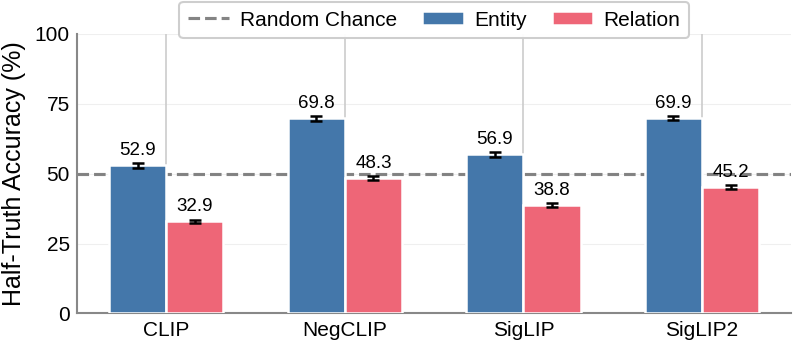


✓ Figure saved to: ../paper_figures/motivation_relational_gap.pdf


In [4]:
# =============================================================================
# MOTIVATION FIGURE: GROUPED BAR CHART (IMPROVED)
# =============================================================================

# Model order (CLIP first as baseline)
model_order = ["CLIP", "NegCLIP", "SigLIP", "SigLIP2"]

# Colorblind-friendly colors from Paul Tol's palette
# Entity = Blue, Relation = Red/Pink (distinguishable for colorblind)
COLORS = {
    'Entity': COLORBLIND_PALETTE[0],    # Blue
    'Relation': COLORBLIND_PALETTE[1],  # Red/Pink
}

# Create figure - SHORTER height so bars aren't too tall
fig, ax = plt.subplots(figsize=(5.5, 2.5), dpi=150)

# Bar settings
x = np.arange(len(model_order))
width = 0.32  # Slightly narrower bars

# Plot bars for each category
for i, category in enumerate(['Entity', 'Relation']):
    cat_data = stats_df[stats_df['category'] == category].set_index('model')
    
    accuracies = [cat_data.loc[m, 'accuracy'] if m in cat_data.index else 0 
                  for m in model_order]
    ci_lows = [cat_data.loc[m, 'accuracy'] - cat_data.loc[m, 'ci_low'] 
               if m in cat_data.index else 0 for m in model_order]
    ci_highs = [cat_data.loc[m, 'ci_high'] - cat_data.loc[m, 'accuracy'] 
                if m in cat_data.index else 0 for m in model_order]
    
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, accuracies, width,
                  yerr=[ci_lows, ci_highs],
                  label=category,
                  color=COLORS[category],
                  edgecolor='white', linewidth=1.2,
                  capsize=3, error_kw={'linewidth': 1.2, 'capthick': 1.2},
                  zorder=3)
    
    # Add value labels on top of bars - no bold
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.annotate(f'{acc:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9, fontweight='normal', color='black')

# Chance line at 50% - subtle styling, added to legend
chance_line = ax.axhline(y=50, color='#666666', linestyle='--', linewidth=1.5, zorder=1, alpha=0.8, label='Random Chance')

# Labels and styling - LARGER text, no bold
ax.set_ylabel('Half-Truth Accuracy (%)', fontsize=12, fontweight='normal', color='black')
ax.set_xlabel('')
ax.set_xticks(x)
ax.set_xticklabels(model_order, fontsize=11, fontweight='normal', color='black')

# Y-axis: 0% to 100% as requested
ax.set_ylim(0, 100)
ax.set_yticks([0, 25, 50, 75, 100])

# X-axis limits
ax.set_xlim(-0.5, len(model_order) - 0.5)

# Legend - positioned at top center, horizontal layout, LARGER font
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3,
          frameon=True, framealpha=0.95, edgecolor='#cccccc', 
          fontsize=10, handletextpad=0.5, columnspacing=1.2,
          labelcolor='black')

# Clean styling - WHITE background (no gray)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='#cccccc', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# Tick styling - LARGER and black
ax.tick_params(axis='both', which='major', labelsize=10, colors='black')

plt.tight_layout()
plt.savefig('../paper_figures/motivation_relational_gap.pdf', bbox_inches='tight', dpi=300)
plt.show()

print("\n✓ Figure saved to: ../paper_figures/motivation_relational_gap.pdf")

In [4]:
# =============================================================================
# PRINT SUMMARY STATISTICS
# =============================================================================

print("\n" + "="*60)
print("SUMMARY: RELATIONAL GAP")
print("="*60)

pivot = stats_df.pivot(index='model', columns='category', values='accuracy')
pivot['Gap'] = pivot['Entity'] - pivot['Relation']  # Gap: Entity is higher than Relation
pivot = pivot.loc[model_order]

print("\nAccuracy (%) - Higher is Better:")
print(pivot.round(1).to_string())

# Improvement over CLIP
clip_entity = pivot.loc['CLIP', 'Entity']
clip_relation = pivot.loc['CLIP', 'Relation']

print("\n" + "-"*60)
print("Improvement over CLIP:")
for model in model_order[1:]:
    entity_improve = pivot.loc[model, 'Entity'] - clip_entity
    relation_improve = pivot.loc[model, 'Relation'] - clip_relation
    print(f"  {model}:")
    print(f"    Entity:   {entity_improve:+.1f}% {'↑' if entity_improve > 0 else '↓'}")
    print(f"    Relation: {relation_improve:+.1f}% {'↑' if relation_improve > 0 else '↓'}")


SUMMARY: RELATIONAL GAP

Accuracy (%) - Higher is Better:
category  Entity  Relation   Gap
model                           
CLIP        53.3      33.2  20.1
NegCLIP     69.8      48.3  21.5
SigLIP      56.9      38.8  18.1
SigLIP2     69.9      45.2  24.7

------------------------------------------------------------
Improvement over CLIP:
  NegCLIP:
    Entity:   +16.5% ↑
    Relation: +15.1% ↑
  SigLIP:
    Entity:   +3.6% ↑
    Relation: +5.6% ↑
  SigLIP2:
    Entity:   +16.6% ↑
    Relation: +12.0% ↑
